In [1]:
import numpy as np
import pandas as pd
import csv

### Some side working to build the code

In [2]:
f = np.load('../data/20231207/node_level_data_cpu_usage.npy', allow_pickle=True)
data = f.item()
data

{'book_info': {'KPI_Label': 'book_info',
  'Node_Name': [],
  'KPI_Feature': ['Latency'],
  'Sequence': array([[ 57.5],
         [ 28. ],
         [ 32.5],
         ...,
         [113. ],
         [111.5],
         [  nan]], shape=(172686, 1)),
  'time': [np.int64(1701855068),
   np.int64(1701855069),
   np.int64(1701855070),
   np.int64(1701855071),
   np.int64(1701855072),
   np.int64(1701855073),
   np.int64(1701855074),
   np.int64(1701855075),
   np.int64(1701855076),
   np.int64(1701855077),
   np.int64(1701855078),
   np.int64(1701855079),
   np.int64(1701855080),
   np.int64(1701855081),
   np.int64(1701855082),
   np.int64(1701855083),
   np.int64(1701855084),
   np.int64(1701855085),
   np.int64(1701855086),
   np.int64(1701855087),
   np.int64(1701855088),
   np.int64(1701855089),
   np.int64(1701855090),
   np.int64(1701855091),
   np.int64(1701855092),
   np.int64(1701855093),
   np.int64(1701855094),
   np.int64(1701855095),
   np.int64(1701855096),
   np.int64(1701855097

In [3]:
sample = []
if 'Node_Name' in data['book_info'] and len(data['book_info']['Node_Name']) >= 0:
    # feature_names.append(f'Node Level | Metric : {kpi_feature}')
    sample.append(f'Node level | Metric :')

sample

['Node level | Metric :']

In [4]:
f = np.load('../data/20231207/pod_level_data_cpu_usage.npy', allow_pickle=True)
data = f.item()
data

{'book_info': {'KPI_Label': 'book_info',
  'Pod_Name': ['adservice-7df8c84f69-zgsdx',
   'alertmanager-main-0',
   'appmesh-controller-6f9b95b4df-8hpjl',
   'aws-load-balancer-controller-69bd799c8c-489sn',
   'aws-load-balancer-controller-69bd799c8c-8mmpq',
   'aws-node-2fjwc',
   'aws-node-4vl7b',
   'aws-node-dhqjr',
   'aws-node-h8428',
   'aws-node-lpnhv',
   'aws-node-nlglf',
   'aws-node-qvp45',
   'aws-node-rkkxj',
   'aws-node-sp6j9',
   'blackbox-exporter-7fff97448c-qhnwv',
   'cart-67fd6f756c-5rh47',
   'carts-b59845878-bhpkg',
   'carts-b59845878-k8t85',
   'carts-b59845878-x57mp',
   'carts-b59845878-zhk8s',
   'carts-b59845878-zm9pw',
   'carts-db-644ff6b576-4qc2m',
   'carts-db-644ff6b576-4wp5k',
   'carts-db-644ff6b576-hc2j2',
   'carts-db-644ff6b576-nk9bw',
   'carts-db-644ff6b576-rrrrq',
   'cartservice-66bdb74f7d-sq84r',
   'catalogue-685db97474-rppn8',
   'catalogue-76688dc8c7-24zcl',
   'catalogue-76688dc8c7-2tcgs',
   'catalogue-76688dc8c7-gkmc6',
   'catalogue-766

# Building a pre-processing function to transform the data

This transforms a given dataset into Quantile Bins so that we can split at valid bins instead of unique values in a given feature

In [5]:
def build_dataset(file_path, kpi_csv_path, anomaly_threshold=90.0):

    # Building the dependent variable y
    print("Building dependent variable y ... 🚀")
    df = pd.read_csv(kpi_csv_file)
    df['Latency'] = df['Latency'].fillna(df['Latency'].mean())

    time_to_latency = {}
    
    for row in df.itertuples(index=False):
        timestamp = int(row.timeStamp)
        latency = float(row.Latency)
        if timestamp not in time_to_latency or latency > time_to_latency[timestamp]:
            time_to_latency[timestamp] = latency

    print("Dependent variable built successfully ✅")
                
    # converting unique timestimaps into master timeline and sorting them since timestamps are always unique and increasing with time
    master_timeline = sorted(list(time_to_latency.keys()))

    # generating binary labels based on anomaly_thershold
    y = np.array([0 if time_to_latency[timestamp] < anomaly_threshold else 1 for timestamp in master_timeline])

    '''
    2. Now processing the .npy files.
    '''

    time_to_features = {time:[] for time in master_timeline}

    print("Building independent variable X ... 🚀")

    # list to store feature names to retrieve feature names using index later for explainability (SHAxP)
    feature_names = []
    
    for file in file_path:
        f = np.load(file, allow_pickle=True)
        data = f.item()

        if 'book_info' not in data:
            continue

        # creating a fast lookup for this file
        timestamps = data['book_info']['time']
        sequence = data['book_info']['Sequence']

        # Gotta use kpi_feature in both pod and node and hence to resolve the local variable issue
        kpi_feature = data['book_info']['KPI_Feature'][0]

        sequence = np.nan_to_num(sequence, nan=0.0)
        # print(f'File being processed and the sequence generated:')
        # print(file, sequence)
    
        time_to_seq = {int(timestamps[i]):sequence[i] for i in range(len(timestamps))}

        row_length = sequence.shape[1]
        zero_pad = np.zeros(row_length)
        
        pod_names = data['book_info'].get('Pod_Name', [])
        node_names = data['book_info'].get('Node_Name', [])

        # print("Number of pods and nodes:", len(pod_names), len(node_names))
        
        if len(pod_names) > 0:
            print("Number of pods:", len(pod_names))
            for i in range(row_length):
                name = pod_names[i] if i < len(pod_names) else f"Unnamed_Pod_{i}"
                feature_names.append(f"Pod: {name} | Metric: {kpi_feature}")
                
        elif len(node_names) > 0:
            print("Number of Nodes:", len(node_names))
            for i in range(row_length):
                name = node_names[i] if i < len(node_names) else f"Unnamed_Node_{i}"
                feature_names.append(f"Node: {name} | Metric: {kpi_feature}")
                
        else:
            # Reaches here for Node files where 'Node_Name' is specifically []
            for i in range(row_length):
                print("Node name not avaiable. Fallback to Cluster Level Metric")
                feature_names.append(f"Cluster Level | Metric: {kpi_feature}")
        
        for t in master_timeline:
            row_data = time_to_seq.get(t, zero_pad)
            time_to_features[t].extend(row_data)

        X = np.array([time_to_features[t] for t in master_timeline])
        master_timeline = np.array(master_timeline)

    print("Building independent variable X is successful ✅")
    print("Dataset built successfully ✅")
    return X, y, master_timeline, feature_names


In [6]:
npy_files = ['../data/20231207/node_level_data_cpu_usage.npy',
            '../data/20231207/node_level_data_memory_usage.npy',
            '../data/20231207/node_level_data_net_disk_io_usage.npy',
            '../data/20231207/node_level_data_net_disk_space_usage.npy',
            '../data/20231207/node_level_data_net_receive.npy',
            '../data/20231207/node_level_data_net_transmit.npy',
            '../data/20231207/pod_level_data_cpu_usage.npy',
            '../data/20231207/pod_level_data_memory_usage.npy',
            '../data/20231207/pod_level_data_rate_received_packets.npy',
            '../data/20231207/pod_level_data_rate_storage_iops.npy',
            '../data/20231207/pod_level_data_rate_transmitted_packets.npy',
            '../data/20231207/pod_level_data_received_bandwidth.npy',
            '../data/20231207/pod_level_data_transmit_bandwidth.npy'
            ]
kpi_csv_file = '../data/20231207/kpi_20231207.csv'

X, y, master_timeline, feature_names = build_dataset(npy_files, kpi_csv_file, anomaly_threshold=85.0)

Building dependent variable y ... 🚀
Dependent variable built successfully ✅
Building independent variable X ... 🚀
Node name not avaiable. Fallback to Cluster Level Metric
Node name not avaiable. Fallback to Cluster Level Metric
Node name not avaiable. Fallback to Cluster Level Metric
Node name not avaiable. Fallback to Cluster Level Metric
Node name not avaiable. Fallback to Cluster Level Metric
Node name not avaiable. Fallback to Cluster Level Metric
Number of pods: 196
Number of pods: 196
Number of pods: 196
Number of pods: 5
Number of pods: 196
Number of pods: 196
Number of pods: 196
Building independent variable X is successful ✅
Dataset built successfully ✅


In [7]:
len(feature_names)

1194

In [8]:
X.shape, y.shape, master_timeline.shape, len(feature_names)

((172686, 1194), (172686,), (172686,), 1194)

# Building the Actual QuantileBinner class

In [9]:
class Node:
    def __init__(self, left=None, right=None, best_feature_to_split=None, threshold_bin=None, *, value=None):
        self.best_feature_to_split = best_feature_to_split
        self.threshold_bin = threshold_bin
        self.left = left
        self.right = right

        self.value = value

        
    def is_leaf_node(self):
        return self.value is not None

class QuantileBinner:
    '''Implementation of Quanitle Binning concept for improved performance

        Purpose: to create bins into which the data points might fall into and append them to the global list @self.bins_per_feature
    '''

    def __init__(self, max_bins=255):
        self.max_bins = max_bins
        self.bins_per_feature = []

    def fit(self, X):
        
        n_features = X.shape[1]

        for feat in range(n_features):
            col = X[:, feat]
            unique_values = np.unique(col)

            if len(unique_values) < self.max_bins:
                self.bins_per_feature.append(unique_values)

            else:
                percentiles = np.linspace(0, 100, self.max_bins)
                bins = np.percentile(col, percentiles)
                self.bins_per_feature.append(np.unique(bins))

        return self

    def transform(self, X):
        # create a matrix like X but dtype strictly to be uint32
        X_binned = np.zeros_like(X, dtype=np.uint32)
        n_features = X.shape[1]
        for feat in range(n_features):
            # X_binned is going to contain: where all the actual values of X at that feature lie in that corresponding bin at that index
            # dictated by self.bins_per_feature (a list of lists containing bins for a feature corresponding to index)
            X_binned[:, feat] = np.searchsorted(self.bins_per_feature[feat], X[:, feat])
            
        return X_binned

# Building the Final QuantileDecisionTree class

In [10]:
class QuantileDecisionTree:
    def __init__(self, max_depth=10, min_samples_leaf=5, min_gain=1e-4, anomaly_weight=10.0):
        self.max_depth = max_depth
        self.max_bins_per_feature = []
        self.min_samples_leaf = min_samples_leaf
        self._n_classes = 2
        self.root = None
        self.anomaly_weight = anomaly_weight
        self.min_gain = min_gain

    def _weighted_gini(self, y):
        m = len(y)
        if m == 0:
            return 0.0
        counts = np.bincount(y, minlength=self._n_classes)
        weighted_counts = np.array([counts[0], counts[1] * self.anomaly_weight])

        total_weight = np.sum(weighted_counts)

        if total_weight == 0.0:
            return 0.0

        probs = weighted_counts / total_weight
        return 1.0 - np.sum(probs ** 2)

    def _best_split(self, X_binned, y):
        n_samples, n_features = X_binned.shape
        best_gain = self.min_gain

        best_feature_idx, best_threshold = None, None

        parent_gini = self._weighted_gini(y)
        total_counts = np.bincount(y, minlength=self._n_classes)

        for feat in range(n_features):
            feat_data = X_binned[:, feat]

            max_bins = self.max_bins_per_feature[feat]

            if max_bins == 0:
                continue
                
            bincount_0 = np.bincount(feat_data[y == 0], minlength=max_bins+1)
            bincount_1 = np.bincount(feat_data[y == 1], minlength=max_bins+1)

            cumsum_0 = np.cumsum(bincount_0)
            cumsum_1 = np.cumsum(bincount_1)

            for thresh in range(max_bins):
                n_left_0 = cumsum_0[thresh]
                n_left_1 = cumsum_1[thresh]

                n_right_0 = total_counts[0] - n_left_0
                n_right_1 = total_counts[1] - n_left_1

                n_left = n_left_0 + n_left_1
                n_right = n_right_0 + n_right_1

                if n_left < self.min_samples_leaf or n_right < self.min_samples_leaf:
                    continue

                wl = np.array([n_left_0, n_left_1 * self.anomaly_weight])
                wr = np.array([n_right_0, n_right_1 * self.anomaly_weight])

                sum_wl = np.sum(wl)
                sum_wr = np.sum(wr)

                gini_left = 1.0 - np.sum((wl / sum_wl) ** 2) if sum_wl > 0 else 0.0
                gini_right = 1.0 - np.sum((wr / sum_wr) ** 2) if sum_wr > 0 else 0.0

                child_gini = (n_left / n_samples) * gini_left + (n_right / n_samples) * gini_right

                information_gain = parent_gini - child_gini

                if information_gain > best_gain:
                    best_feature_idx = feat
                    best_threshold = thresh
                    best_gain = information_gain

        return best_feature_idx, best_threshold

        
    def _compute_leaf_value(self, y):
        return np.argmax(np.bincount(y, minlength=self._n_classes))
                
    
    def _build_tree(self, X_binned, y, depth=0):

        # recursion stop conditions
        if depth > self.max_depth or len(np.unique(y)) == 1:
            leaf_value = self._compute_leaf_value(y)
            return Node(value=leaf_value)

        best_feature_idx, best_threshold = self._best_split(X_binned, y)

        if best_feature_idx is None:
            leaf_value = self._compute_leaf_value(y)
            return Node(value=leaf_value)

        left_mask = X_binned[:, best_feature_idx] <= best_threshold
        right_mask = ~left_mask

        y_left, y_right = y[left_mask], y[right_mask]

        left_child = self._build_tree(X_binned[left_mask], y_left, depth+1)
        right_child = self._build_tree(X_binned[right_mask], y_right, depth+1)

        return Node(left=left_child, right=right_child, best_feature_to_split=best_feature_idx, threshold_bin=best_threshold)

    def fit(self, X_binned, y):
        n_features = X_binned.shape[1]
        self.max_bins_per_feature = [np.max(X_binned[:, feat]) if len(X_binned[:, feat]) > 0 else 0 for feat in range(n_features)]
        self.root = self._build_tree(X_binned, y, depth=0)

    def predict(self, X_binned):
        return np.array([self._predict_row(x, self.root) for x in X_binned])

    def _predict_row(self, x, node):
        if node.value is not None:
            return node.value

        if x[node.best_feature_to_split] <= node.threshold_bin:
            return self._predict_row(x, node.left)

        else:
            return self._predict_row(x, node.right)

    def explain_prediction(self, x_raw, x_binned, binner, feature_names, node=None, depth=0, path=None):
        if node is None:
            node = self.root
            path = ["--- Prediction Explanation Path ---"]

        if node.value is not None:
            status = 'ANOMALY' if node.value == 1 else 'NORMAL'
            path.append(f'{"    " * depth} -> Final Classification: {status}')
            return "\n".join(path)

        feat_name = feature_names[node.best_feature_to_split]
        actual_value = x_raw[node.best_feature_to_split]

        split_value = binner.bins_per_feature[node.best_feature_to_split][node.threshold_bin]

        if x_binned[node.best_feature_to_split] <= node.threshold_bin:
            path.append(f'{"    " * depth} -> Moving [LEFT] - Feature name : {feat_name}, Value : {actual_value:.4f} <= Threshold : {split_value:.4f}')
            return self.explain_prediction(x_raw, x_binned, binner, feature_names, node.left, depth + 1, path)

        else:
            path.append(f'{"    " * depth} -> Moving [RIGHT] - Feature name : {feat_name}, Value : {actual_value:.4f} > Threshold : {split_value:.4f}')
            return self.explain_prediction(x_raw, x_binned, binner, feature_names, node.right, depth + 1, path)


# Fitting the data into bins and calling in for predictions

In [11]:
import numpy as np

binner = QuantileBinner(max_bins=255)
binner.fit(X)

# Transform the continuous data into integer bins
X_binned = binner.transform(X)

tree = QuantileDecisionTree(max_depth=6, anomaly_weight=50.0)
tree.fit(X_binned, y)

# Generate predictions across the dataset
predictions = tree.predict(X_binned)

In [12]:
def evaluate_anomaly_model(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    # Calculate exact matches and mismatches
    true_positives = np.sum((y_true == 1) & (y_pred == 1))
    true_negatives = np.sum((y_true == 0) & (y_pred == 0))
    false_positives = np.sum((y_true == 0) & (y_pred == 1))
    false_negatives = np.sum((y_true == 1) & (y_pred == 0))

    # Calculate metrics with zero-division protection
    accuracy = (true_positives + true_negatives) / len(y_true) if len(y_true) > 0 else 0.0
    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0.0
    recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0.0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

    print("--- Model Evaluation ---")
    print(f"Total Samples Tested: {len(y_true)}")
    print(f"True Positives (Anomalies Caught): {true_positives}")
    print(f"False Negatives (Anomalies Missed): {false_negatives}")
    print(f"False Positives (False Alarms): {false_positives}")
    print(f"True Negatives (Normal Correct): {true_negatives}")
    print("-" * 24)
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}  <- (Of all predicted anomalies, how many were real?)")
    print(f"Recall:    {recall:.4f}  <- (Of all actual anomalies, how many did we catch?)")
    print(f"F1-Score:  {f1_score:.4f}")

    return precision, recall, f1_score

# Run the evaluation
precision, recall, f1 = evaluate_anomaly_model(y, predictions)

--- Model Evaluation ---
Total Samples Tested: 172686
True Positives (Anomalies Caught): 72287
False Negatives (Anomalies Missed): 0
False Positives (False Alarms): 7204
True Negatives (Normal Correct): 93195
------------------------
Accuracy:  0.9583
Precision: 0.9094  <- (Of all predicted anomalies, how many were real?)
Recall:    1.0000  <- (Of all actual anomalies, how many did we catch?)
F1-Score:  0.9525


Saved: confusion_matrix.png


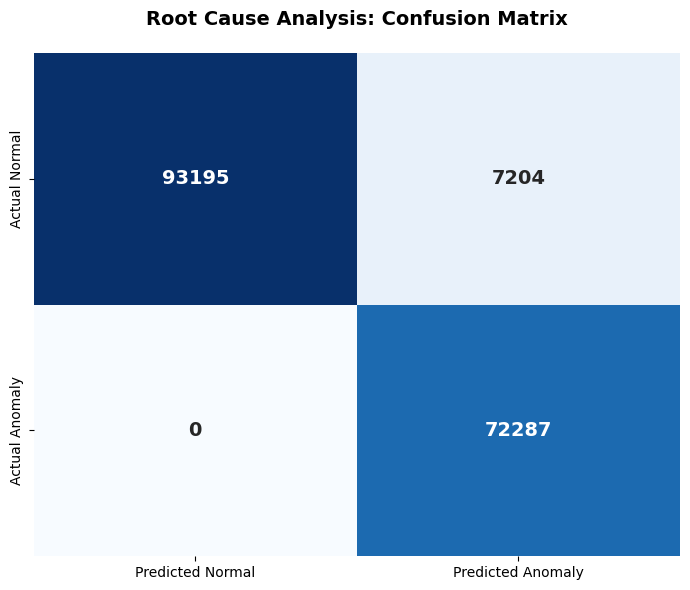

In [13]:
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay, roc_curve, auc
from matplotlib import pyplot as plt
import seaborn as sns

cm = confusion_matrix(y, predictions)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Normal', 'Predicted Anomaly'],
            yticklabels=['Actual Normal', 'Actual Anomaly'],
            annot_kws={"size": 14, "weight": "bold"})

ax.set_title('Root Cause Analysis: Confusion Matrix', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('./assets/confusion_matrix.png', dpi=300)
print("Saved: confusion_matrix.png")

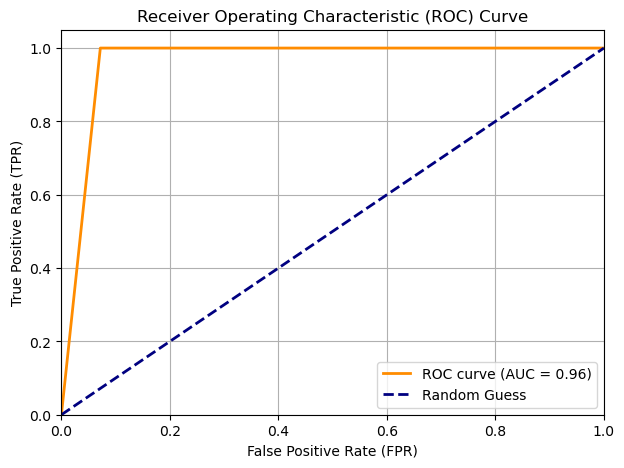

In [14]:
fpr, tpr, thresholds = roc_curve(y, predictions)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

# Explain prediction method in action

In [15]:
# Find the indices of all rows where the model predicted an anomaly
anomaly_indices = np.where(predictions == 1)[0]
normal_indices = np.where(predictions == 0)[0]

if len(anomaly_indices) > 0:
    # Take the very first anomaly found
    target_idx = anomaly_indices[125]
    
    print(f"\nAnalyzing Data Point at Index {target_idx}:", tree.explain_prediction(
        x_raw=X[target_idx], 
        x_binned=X_binned[target_idx], 
        binner=binner, 
        feature_names=feature_names
    ))
else:
    print("\nNo anomalies were predicted by the model. Try increasing anomaly_weight.")


Analyzing Data Point at Index 3705: --- Prediction Explanation Path ---
 -> Moving [RIGHT] - Feature name : Cluster Level | Metric: Latency, Value : 62.0000 > Threshold : 48.5000
     -> Final Classification: ANOMALY


In [16]:
target_idx = normal_indices[51]
    
print(f"\nAnalyzing Data Point at Index {target_idx}:", tree.explain_prediction(
    x_raw=X[target_idx], 
    x_binned=X_binned[target_idx], 
    binner=binner, 
    feature_names=feature_names
))


Analyzing Data Point at Index 53: --- Prediction Explanation Path ---
 -> Moving [LEFT] - Feature name : Cluster Level | Metric: Latency, Value : 26.5000 <= Threshold : 48.5000
     -> Final Classification: NORMAL


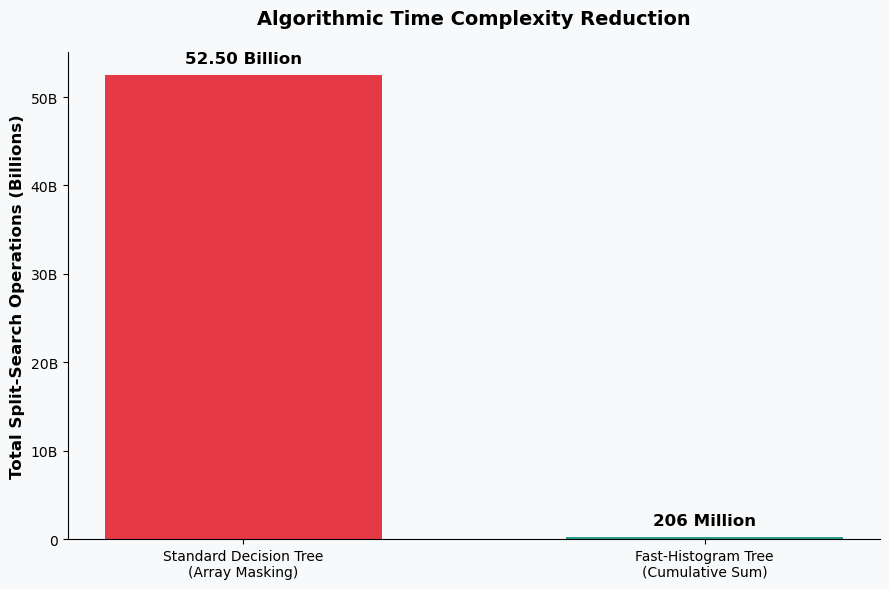

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Data
methods = ['Standard Decision Tree\n(Array Masking)', 'Fast-Histogram Tree\n(Cumulative Sum)']
operations = [52500000000, 206000000]  # 52.5 Billion vs 206 Million

# Setup figure
plt.figure(figsize=(9, 6), facecolor='#f8f9fa')
ax = plt.axes()
ax.set_facecolor('#f8f9fa')

# Create bars
bars = plt.bar(methods, operations, color=['#e63946', '#2a9d8f'], width=0.6)

# Format the Y-axis to show Billions
plt.ylabel('Total Split-Search Operations (Billions)', fontsize=12, fontweight='bold')
ax.set_yticks([0, 10e9, 20e9, 30e9, 40e9, 50e9])
ax.set_yticklabels(['0', '10B', '20B', '30B', '40B', '50B'])

# Remove top and right spines for a cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add exact value labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    label = f"{yval / 1e9:.2f} Billion" if yval > 1e9 else f"{yval / 1e6:.0f} Million"
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1e9, 
             label, ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Algorithmic Time Complexity Reduction', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()

# Save the visual
plt.savefig('./assets/performance_benchmark.png', dpi=300, bbox_inches='tight')
plt.show()

Saved: pr_tradeoff.png


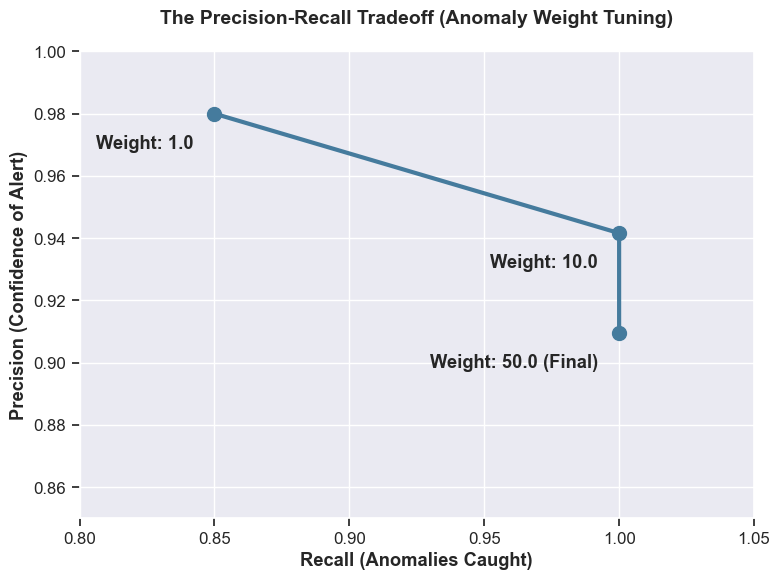

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set global visual style for a clean, professional look
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_context("notebook", font_scale=1.1)

# ==========================================
# Audience: Data Scientists & ML Engineers
# Story: Deliberately sacrificed a tiny bit of precision to guarantee 100% anomaly capture.
# ==========================================
def plot_precision_recall_concept():
    # A conceptual curve mimicking my anomaly_weight tuning journey
    weights = ['Weight: 1.0', 'Weight: 10.0', 'Weight: 50.0 (Final)']
    precision = [0.98, 0.9416, 0.9094]
    recall = [0.85, 1.0000, 1.0000]
    
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(recall, precision, marker='o', markersize=10, linestyle='-', linewidth=3, color='#457b9d')
    
    for i, txt in enumerate(weights):
        ax.annotate(txt, (recall[i], precision[i]), xytext=(-15, -25), 
                    textcoords='offset points', ha='right', fontweight='bold')
        
    ax.set_xlabel('Recall (Anomalies Caught)', fontweight='bold')
    ax.set_ylabel('Precision (Confidence of Alert)', fontweight='bold')
    ax.set_title('The Precision-Recall Tradeoff (Anomaly Weight Tuning)', fontsize=14, fontweight='bold', pad=20)
    ax.set_xlim(0.80, 1.05)
    ax.set_ylim(0.85, 1.0)
    
    plt.tight_layout()
    plt.savefig('./assets/pr_tradeoff.png', dpi=300)
    print("Saved: pr_tradeoff.png")

plot_precision_recall_concept()

# Saving model artifacts

In [19]:
import pickle as pkl

model_artifacts = {
    'X_raw': X,
    'X_binned': X_binned,
    'tree': tree,
    'binner': binner,
    'feature_names': feature_names,
}

with open('artifacts.pkl', 'wb') as file:
    pkl.dump(model_artifacts, file)

print("Artifacts pickled and exported successfully ... ✅")

Artifacts pickled and exported successfully ... ✅
